In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)
     

Running on: cpu


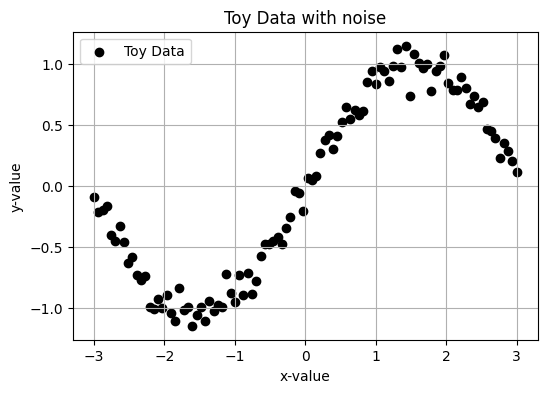

Initial w: -0.14153707420504144
Initial b: -0.04206453227653591


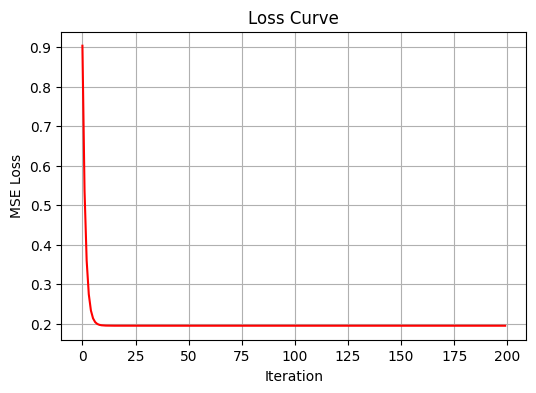

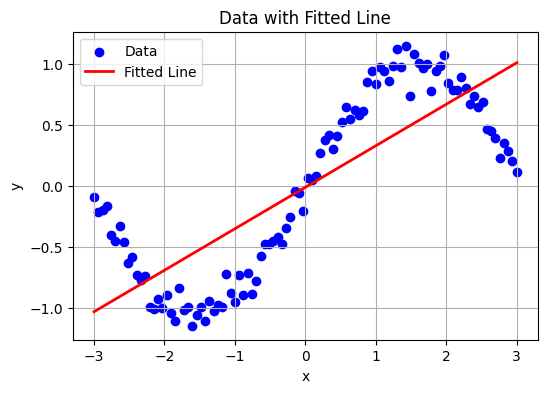

In [38]:
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

#ploting the data 
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='black', label='Toy Data')
plt.title("Toy Data with noise")
plt.xlabel("x-value")
plt.ylabel("y-value")
plt.legend()
plt.grid(True)
plt.show()


#Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

print("Initial w:", w)
print("Initial b:", b)

lr = 0.05
num_steps = 200
loss_history = []

for step in range(num_steps):

    # Forward pass
    y_hat = w * x + b

    # Compute loss
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # Compute gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    #Update parameters
    w = w - lr * dw
    b = b - lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# (a) Loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history, color='red')
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# (b) Data with fitted line
y_hat = w * x + b

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_hat, color='red', linewidth=2, label='Fitted Line')
plt.title("Data with Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()





![Derivative](der.png) 
```python
dw = np.mean(2 * (y_hat - y) * x)
```

because `np.mean(...)` computes the average, which is equivalent ecause `np.mean(...)` computes the average, which is equivalent to

$$
\frac{1}{n}\sum.
$$



The model is underfitting.

A single neuron can only learn a linear relationship since its formula for pridicition is a straight line 

however the target function which is 
$$
\hat{y}=wx+b,
$$

which represents a straight line. However, the target function

$$
y=\sin(x)
$$

is non-linear and continuouslt curves up and down.No mattere how trained a model is , adjusting the weight (w) and bias (b) only changes the slope and the position of the line.it cannot produce the curved shape of a sine wave.

Initially, the loss decreases as the model identifies the best possible straight-line relationship. However, after a certain point, the loss stops improving because the model has reached the limits of its capacity. This demonstrates **underfitting**, where the model is too simple to effectively capture the true pattern present in the data.


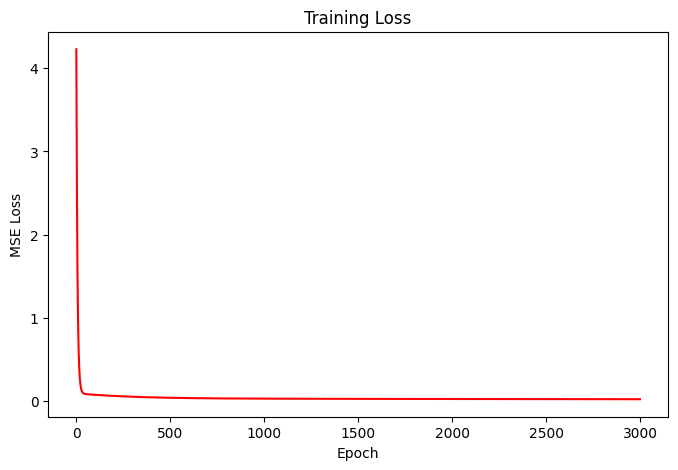

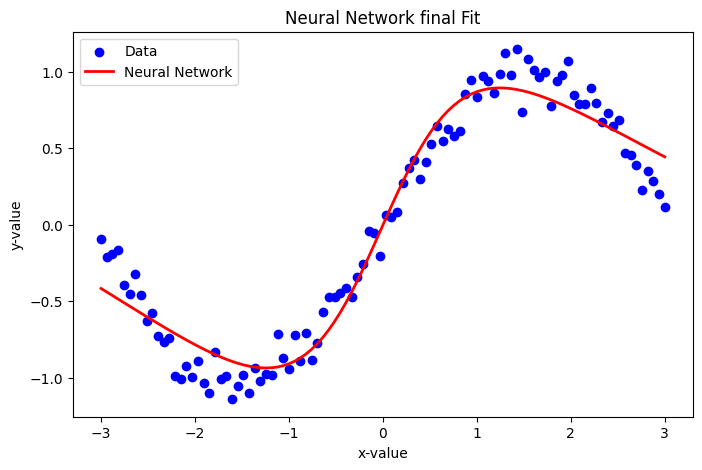

In [39]:

# Make x and y column vectors
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ W1 + b1 
h  = np.tanh(z1) 
y_hat = h @ W2 + b2 
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
lr = 0.01
epochs = 3000

loss_history = []

for epoch in range(epochs):
  z1 = x @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y) ** 2)
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  # Update
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2
  loss_history.append(loss)

  # TODO: Plot the loss curve AND the final fit over the data.

plt.figure(figsize=(8,5))
plt.plot(loss_history, color="red")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data", color="blue")
plt.plot(x, y_hat, color="red", linewidth=2, label="Neural Network")
plt.title("Neural Network final Fit")
plt.xlabel("x-value")
plt.ylabel("y-value")
plt.legend()
plt.show()

Without the tanh activation function, every layer only performs a linear operation. Combining several linear layers still gives a linear model, so the network behaves like a single neuron. As a result, it can only learn a straight-line relationship and cannot fit the curved shape of the sine function.

The hidden layer computes
$$
h = xW_1 + b_1,
$$

and the output layer computes

$$
\hat{y} = hW_2 + b_2.
$$

Substituting the first equation into the second gives

$$
\hat{y} = (xW_1 + b_1)W_2 + b_2.
$$

Expanding,

$$
\hat{y} = x(W_1W_2) + (b_1W_2 + b_2).
$$

Let

$$
W = W_1W_2
\quad \text{and} \quad
b = b_1W_2 + b_2.
$$

Then the equation becomes

$$
\boxed{\hat{y} = xW + b}
$$

Q2.
he 8 hidden neurons each learned a different feature of the sine wave. Using the tanh activation function, they produced different non-linear outputs, which the output neuron combined to create a curve that closely matched the target function.

Q3.
Backpropagation is the process the network uses to learn. It calculates the prediction error, determines how much each weight contributed to that error, and updates the weights to improve the model's accuracy over time.


C:\Users\USER\AppData\Local\Temp\ipykernel_19376\2442792636.py:21: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
C:\Users\USER\AppData\Local\Temp\ipykernel_19376\2442792636.py:30: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\USER\AppData\Local\Temp\ipykernel_19376\2442792636.py:31: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


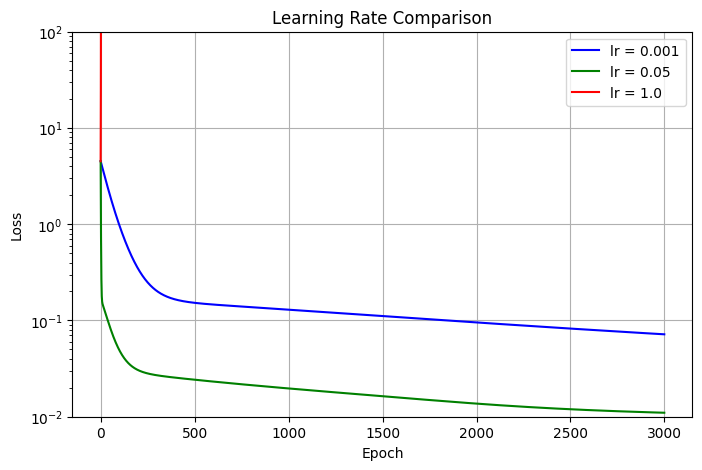

In [40]:
# Wrap the training loop in a function
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)

    # Initialize weights
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(steps):
        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        # Loss
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


# Train with three learning rates
loss_1 = train_toy(0.001)
loss_2 = train_toy(0.05)
loss_3 = train_toy(1.0)

## Plot the loss curves
plt.figure(figsize=(8,5))

plt.plot(loss_1, color="blue", label="lr = 0.001")
plt.plot(loss_2, color="green", label="lr = 0.05")
plt.plot(loss_3, color="red", label="lr = 1.0")

plt.yscale("log")

plt.ylim(1e-2, 100) # Setting y-axis limits for better visibility

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.show()

The learning rate determines how quickly the model updates its parameters during training.

* **0.001:** The loss decreases slowly because the updates are very small, resulting in slow convergence.
* **0.05:** The loss drops quickly and stabilizes, providing fast and stable learning.
* **1.0:** The loss oscillates or increases because the updates are too large, causing the model to overshoot the minimum.

A very large learning rate does not improve training speed. Instead, it causes the model to skip over the optimal solution, preventing the loss from converging.


In [49]:
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# Binary yes/no columns
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
    if col in obesity.columns and not pd.api.types.is_numeric_dtype(obesity[col]):
        obesity[col] = obesity[col].astype(str).str.lower().map({"yes": 1, "no": 0})

# Gender (binary)
if "Gender" in obesity.columns and not pd.api.types.is_numeric_dtype(obesity["Gender"]):
    obesity["Gender"] = obesity["Gender"].replace(
        {"Male": 1, "Female": 0, "male": 1, "female": 0}
    )

# Ordinal columns
ordinal_cols = [
    col
    for col in ["CAEC", "CALC"]
    if col in obesity.columns and not pd.api.types.is_numeric_dtype(obesity[col])
]
if ordinal_cols:
    ordinal_encoder = OrdinalEncoder()
    obesity[ordinal_cols] = ordinal_encoder.fit_transform(obesity[ordinal_cols])

# Nominal column
if "MTRANS" in obesity.columns:
    obesity = pd.get_dummies(obesity, columns=["MTRANS"], drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
if "BMI" not in obesity.columns:
    obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
if "NObeyesdad" in obesity.columns and not pd.api.types.is_numeric_dtype(
    obesity["NObeyesdad"]
):
    label_encoder = LabelEncoder()
    obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])

  
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,


X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

X_train, X_temp, y_train, y_temp = train_test_split(
  X,
  y,
  test_size=0.4,
  stratify=y,
  random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
  X_temp,
  y_temp,
  test_size=0.5,
  stratify=y_temp,
  random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.

# StandardScaler
scaler = StandardScaler()

# Fit ONLY on train, transform train, val, and test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:


# Convert to Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
# Wrap in TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Training: (1266, 20)
Validation: (422, 20)
Test: (423, 20)


Q1.
CrossEntropyLoss uses integer labels because it directly selects the correct class index instead of processing a one-hot vector. This reduces memory usage and improves computation speed.


Q2.
Neural networks use gradients to update weights. Large feature values produce large gradients, making training unstable. Scaling keeps gradients balanced, leading to faster and more stable learning.
Neural networks, however, update their weights using gradient descent. The gradient equation for a weight is:
$$
\frac{\partial L}{\partial w} = 
\frac{\partial L}{\partial z} . x
$$
Since the weight update directly depends on the input feature value X
, an unscaled feature with huge numbers will create huge gradients. This makes training unstable and forces gradient descent to bounce around wildly. Scaling keeps all gradients on a balanced level so the network learns smoothly.


Q3
shuffle=True randomly rearranges the training data before each epoch. This prevents the model from learning patterns based on data order and improves generalization.

In [53]:
# TODO: Define a FeedForwardNet class (subclass nn.Module)
class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
    super().__init__()
    h1, h2 = hidden_sizes
    
    # Layer 1: Input to First Hidden Layer
    self.fc1 = nn.Linear(input_dim, h1)
    self.relu1 = nn.ReLU()
    
    # Layer 2: First Hidden Layer to Second Hidden Layer
    self.fc2 = nn.Linear(h1, h2)
    self.relu2 = nn.ReLU()
    
    # Layer 3: Second Hidden Layer to Output Logits
    self.out = nn.Linear(h2, n_classes)
      
  def forward(self, x):
    x = self.relu1(self.fc1(x))
    x = self.relu2(self.fc2(x))
    x = self.out(x)
    return x

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_scaled.shape[1] 
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)

print(model)


# TODO: Count trainable parameters:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")

# Hand-calculated parameter count for Layer 1
layer1_params_hand = input_dim * 64 + 64
print(f"Hand-calculated Layer 1 Parameters: {layer1_params_hand}")

FeedForwardNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (out): Linear(in_features=32, out_features=7, bias=True)
)

Total Trainable Parameters: 3655
Hand-calculated Layer 1 Parameters: 1344


Layer 1: nn.Linear(20, 64)
Weights = 20×64=1280
Biases = 64

Total parameters:

1280+64=
1344
	​

Layer 2: nn.Linear(64, 32)
Weights = 64×32=2048
Biases = 32

Total parameters:

2048+32=
2080

Output Layer: nn.Linear(32, 7)
Weights = 32×7=224
Biases = 7

Total parameters:

224+7=
231
	​

Total Trainable Parameters
1344+2080+231=
3655

Q2.
ReLU is used because it helps reduce the vanishing gradient problem, allowing the network to train faster and more effectively. Unlike tanh, ReLU does not squash positive values into a small range, making it easier for gradients to propagate through deeper networks.

Q3.
If the ReLU activation functions were removed, the network would consist only of linear layers. Since the composition of multiple linear transformations is still a single linear transformation, the entire network would behave like one linear model
$$
y = Wx + b
$$
as a result, the network would only be able to learn linear relationships and would lose its ability to model nonlinear patterns in the data.
	​

	​


Epoch 01/50 | Train Loss: 1.8011 - Acc: 0.3752 | Val Loss: 1.6537 - Acc: 0.5450
Epoch 02/50 | Train Loss: 1.4352 - Acc: 0.5782 | Val Loss: 1.2580 - Acc: 0.6351
Epoch 03/50 | Train Loss: 1.0611 - Acc: 0.6675 | Val Loss: 0.9738 - Acc: 0.6967
Epoch 04/50 | Train Loss: 0.8222 - Acc: 0.7409 | Val Loss: 0.8069 - Acc: 0.7630
Epoch 05/50 | Train Loss: 0.6614 - Acc: 0.8009 | Val Loss: 0.6908 - Acc: 0.7867
Epoch 06/50 | Train Loss: 0.5428 - Acc: 0.8325 | Val Loss: 0.6089 - Acc: 0.8294
Epoch 07/50 | Train Loss: 0.4550 - Acc: 0.8760 | Val Loss: 0.5428 - Acc: 0.8483
Epoch 08/50 | Train Loss: 0.3845 - Acc: 0.8949 | Val Loss: 0.5014 - Acc: 0.8436
Epoch 09/50 | Train Loss: 0.3359 - Acc: 0.9013 | Val Loss: 0.4675 - Acc: 0.8626
Epoch 10/50 | Train Loss: 0.2980 - Acc: 0.9131 | Val Loss: 0.4388 - Acc: 0.8649
Epoch 11/50 | Train Loss: 0.2602 - Acc: 0.9242 | Val Loss: 0.4252 - Acc: 0.8697
Epoch 12/50 | Train Loss: 0.2322 - Acc: 0.9352 | Val Loss: 0.4133 - Acc: 0.8934
Epoch 13/50 | Train Loss: 0.2090 - Acc: 

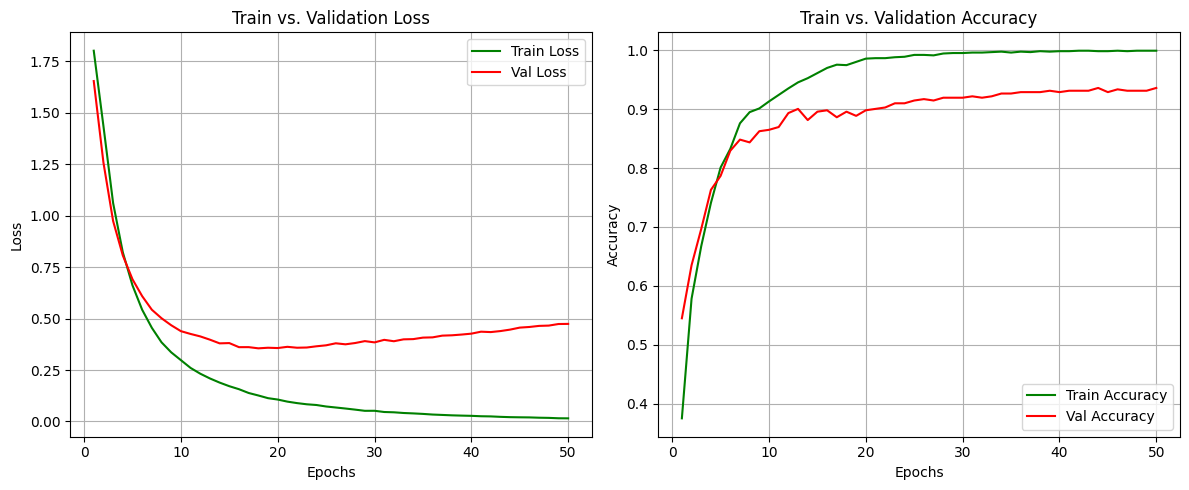

In [54]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# Tracking history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

EPOCHS = 50
best_val_acc = 0.0
best_model_weights = None

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
for epoch in range(1, EPOCHS + 1):
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += xb.size(0)
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    #   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
    #   3. Append everything to history lists; print a one-line summary per epoch.
    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            logits = model(xb)
            loss = criterion(logits, yb)
            
            val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    # Append everything to history lists
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # Print summary per epoch
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}")

    # TODO: Save the best model (highest validation accuracy):
    # Track and save best model weights
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "ffn_best.pt")


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} (Saved to ffn_best.pt)")

# --- TODO: Plot Loss and Accuracy Curves ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', color="green")
plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Val Loss', color="red")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs. Validation Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Train Accuracy', color="green")
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Val Accuracy', color="red")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs. Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()